# Aula 2 — Introdução ao Machine Learning
## *Ou: como ensinar um computador a prever o preço de diamantes*

**Professores:**
- Jhonatan Ramos
- Vinícius "Mumu" Rodrigues

---

## 🤔 Antes de começar: uma pergunta

Imagina que você quer comprar um diamante (sim, por que não?).

Você vai até uma joalheria e o vendedor te fala: *"Esse aqui custa R$ 50.000"*.

Você pergunta: **por quê?**

Ele responde: *"Depende do tamanho, da cor, da clareza, do corte..."*

Aí você pensa: *"Será que eu consigo prever o preço de um diamante só olhando para essas características?"*

**Spoiler: sim. E é exatamente isso que vamos aprender hoje.**

---

## 1. O que é Machine Learning?

### A versão humana de aprender

Quando você era criança, como aprendeu que um cachorro é um cachorro?

Alguém ficou te mostrando vários animais diferentes e dizendo: *"Esse é cachorro. Esse também. Aquele é gato, não é cachorro."*

Com o tempo, você internalizou um padrão: *"cachorro tem focinho assim, late, tem 4 patas..."* — e hoje você reconhece um cachorro sem precisar que ninguém te diga.

**Machine Learning funciona exatamente assim, mas para computadores.**

### A definição (simples)

> Machine Learning (ou Aprendizado de Máquina) é uma forma de ensinar o computador a encontrar padrões em dados, sem precisar programar explicitamente cada regra.

Em vez de você dizer ao computador *"se o diamante tiver mais de 2 quilates E a cor for D, então custa acima de R$ 30.000"*, você simplesmente mostra vários exemplos de diamantes com seus preços — e o computador **aprende sozinho** qual é a relação.

### Comparando: a abordagem antiga vs ML

| Abordagem Tradicional | Machine Learning |
|---|---|
| Você escreve as regras | O computador descobre as regras |
| Funciona só para casos previstos | Funciona para casos novos |
| Difícil de atualizar | Aprende com novos dados |

---

## 2. O que é um "Modelo"?

### A analogia do funcionário novo

Imagina que você contratou alguém novo na empresa para avaliar propostas comerciais.

No primeiro dia, você senta com ele e mostra **100 propostas antigas** que já foram avaliadas, dizendo: *"Essa aqui foi aprovada, essa foi rejeitada, essa foi aprovada..."*

O funcionário estuda tudo aquilo, aprende o padrão de decisão da empresa, e depois começa a avaliar **propostas novas** por conta própria.

**Esse funcionário é o modelo de Machine Learning.**

- O processo de estudo = **treinamento**
- As 100 propostas antigas = **dados de treinamento**
- A avaliação das propostas novas = **previsão (predição)**

### Formalizando

Um **modelo** é uma função matemática (não se assuste!) que recebe características de uma coisa como entrada e retorna uma previsão como saída.

```
Características do diamante → [MODELO] → Preço previsto
(quilate, cor, corte...)               (R$ 12.500)
```

---

## 3. Treino vs. Teste — por que dividir os dados?

### A analogia da prova

Imagina que o professor vai aplicar uma prova com 100 questões.

Dois alunos estudam de formas diferentes:

- **Aluno A:** decora as respostas das 100 questões que serão cobradas.
- **Aluno B:** estuda o conteúdo de verdade.

Na prova, o Aluno A vai bem. Mas se o professor mudar as questões? O Aluno A se dá mal.

O mesmo problema acontece em ML. Se o modelo *decorar* os dados de treino em vez de aprender o padrão real, ele vai falhar nos dados novos.

### A solução: separar treino e teste

Por isso, **nunca treinamos e avaliamos o modelo nos mesmos dados**. A lógica é:

1. Pegamos nosso conjunto de dados completo
2. Separamos uma parte para **treinar** (o modelo aprende com esses)
3. Guardamos outra parte para **testar** (o modelo nunca viu esses — é a "prova" real)

```
Dados completos (100%)
├── Treino (80%) → o modelo aprende aqui
└── Teste  (20%) → avaliamos se ele aprendeu de verdade
```

A divisão mais comum é **80% treino / 20% teste**.

---

## 4. Nosso dataset: Diamantes 💎

Vamos trabalhar com o famoso dataset **diamonds**, que contém informações sobre ~54.000 diamantes.

### Variáveis do dataset:

| Coluna | O que é |
|---|---|
| `carat` | Peso do diamante em quilates (tamanho) |
| `cut` | Qualidade do corte (Fair, Good, Very Good, Premium, Ideal) |
| `color` | Cor (J = pior → D = melhor) |
| `clarity` | Clareza/pureza (I1 = pior → IF = melhor) |
| `depth` | Profundidade percentual |
| `table` | Largura do topo em relação ao ponto mais largo |
| `x`, `y`, `z` | Dimensões físicas em mm |
| `price` | **Preço em dólares (nosso alvo!)** |

**Nosso objetivo:** prever o preço (`price`) a partir das outras características.

Vamos carregar os dados:

In [1]:
# Importando as bibliotecas que vamos usar
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando o dataset direto do seaborn (sem precisar baixar nada!)
df = sns.load_dataset('diamonds')

# Primeiras linhas
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [2]:
# Quantos diamantes temos?
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 53940
Colunas: 10


In [3]:
# Informações gerais: tipos de dados e valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [4]:
# Estatísticas básicas das colunas numéricas
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


### Exploração rápida: entendendo os dados visualmente

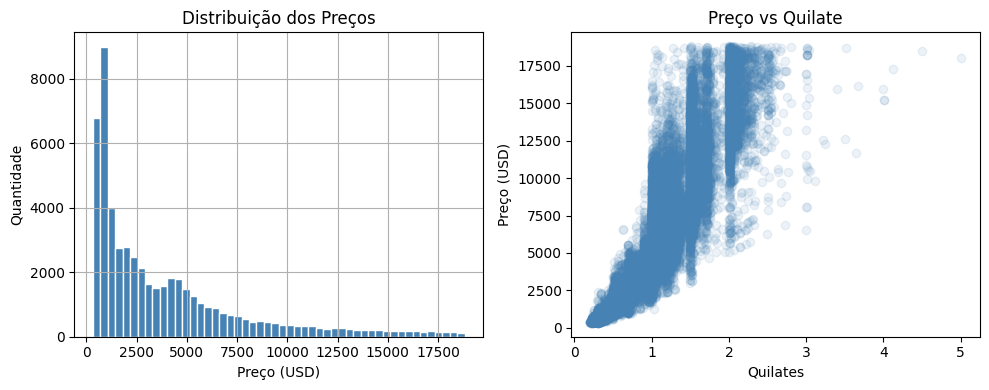

In [5]:
# Distribuição do preço
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['price'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribuição dos Preços')
plt.xlabel('Preço (USD)')
plt.ylabel('Quantidade')

# Preço vs Quilate
plt.subplot(1, 2, 2)
plt.scatter(df['carat'], df['price'], alpha=0.1, color='steelblue')
plt.title('Preço vs Quilate')
plt.xlabel('Quilates')
plt.ylabel('Preço (USD)')

plt.tight_layout()
plt.show()

C:\Users\jhona\AppData\Local\Temp\ipykernel_10820\3848176038.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cut')['price'].mean().sort_values().plot(kind='bar', color='steelblue', edgecolor='white')


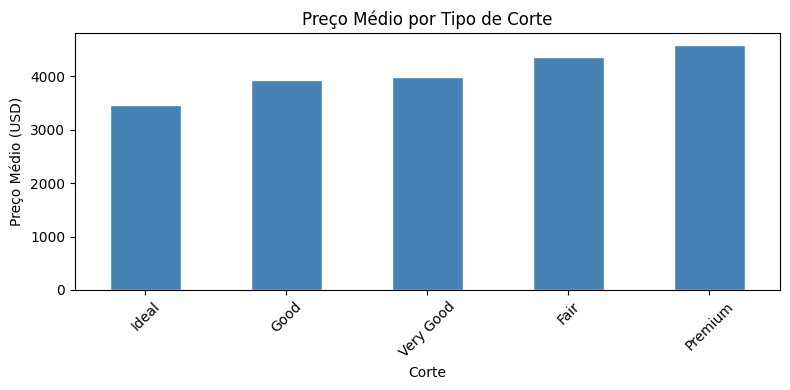

In [6]:
# Preço médio por qualidade de corte
plt.figure(figsize=(8, 4))
df.groupby('cut')['price'].mean().sort_values().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Preço Médio por Tipo de Corte')
plt.xlabel('Corte')
plt.ylabel('Preço Médio (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Observação curiosa:** diamantes com corte "Ideal" não são os mais caros em média. Isso acontece porque diamantes menores (mais baratos) tendem a ter cortes mais elaborados. Isso mostra que dados escondem histórias — e é por isso que análise exploratória importa!

---

## 5. Problema: os dados não estão prontos para o modelo 😬

Vamos olhar os tipos de dado de cada coluna:

In [7]:
df.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Percebeu o problema?

As colunas `cut`, `color` e `clarity` são do tipo **`category`** — ou seja, são textos/categorias.

E modelos de Machine Learning trabalham com **números**. Eles não sabem o que significa "Ideal" ou "Good".

É como tentar somar "maçã" + "laranja". Não funciona.

**Precisamos transformar texto em número. Esse processo se chama: Pré-processamento.**

---

## 6. Pré-processamento de Dados

O pré-processamento é a etapa em que deixamos os dados no formato que o modelo consegue entender e trabalhar bem.

São dois grandes passos:
1. **Encoding** → transformar categorias em números
2. **Scaling** → colocar todas as variáveis na mesma escala

---

### 6.1. Encoding — transformando texto em número

#### O que é?

Imagine que você vai preencher um formulário e precisa colocar seu estado civil. Em vez de escrever "casado", você marca a opção **2** (onde: 1=solteiro, 2=casado, 3=divorciado).

Isso é encoding: substituir categorias por números.

#### Dois tipos principais:

**Label Encoding** — atribui um número para cada categoria:
```
Fair → 0
Good → 1
Very Good → 2
Premium → 3
Ideal → 4
```

✅ Funciona bem quando as categorias têm uma ordem natural (como qualidade: ruim → bom → ótimo)

**One-Hot Encoding** — cria uma coluna separada para cada categoria, com 0 ou 1:
```
         cut_Fair  cut_Good  cut_VeryGood  cut_Premium  cut_Ideal
diamante1    0         0           0            1            0
diamante2    0         0           0            0            1
```

✅ Funciona bem quando as categorias **não têm ordem** (como cor de carro: azul, verde, vermelho)

No nosso caso, as três colunas (`cut`, `color`, `clarity`) têm uma ordem natural (de pior para melhor), então vamos usar Label Encoding.

In [8]:
# Importando o LabelEncoder do scikit-learn
from sklearn.preprocessing import LabelEncoder

# Fazemos uma cópia do dataframe para não bagunçar o original
df_modelo = df.copy()

# Criamos um encoder
le = LabelEncoder()

# Aplicamos nas colunas categóricas
colunas_categoricas = ['cut', 'color', 'clarity']

for coluna in colunas_categoricas:
    df_modelo[coluna] = le.fit_transform(df_modelo[coluna])
    print(f"Coluna '{coluna}': {df[coluna].unique()} → {df_modelo[coluna].unique()}")

Coluna 'cut': ['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair'] → [2 3 1 4 0]
Coluna 'color': ['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J'] → [1 5 6 4 2 3 0]
Coluna 'clarity': ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'] → [3 2 4 5 7 6 0 1]


In [9]:
# Conferindo como ficou
df_modelo.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


Agora todas as colunas são numéricas. ✅

---

### 6.2. Scaling — colocando tudo na mesma escala

#### Por que isso importa? Uma analogia

Imagine que você vai avaliar jogadores de futebol usando duas métricas:
- **Gols marcados:** varia de 0 a 50 na temporada
- **Passes certos (%):** varia de 0 a 100

Se você simplesmente somar as duas métricas, os passes vão dominar o resultado só por terem escala maior — mesmo que gols sejam mais importantes!

O mesmo acontece nos modelos de ML. Se uma variável vai de 0 a 1 e outra vai de 0 a 10.000, o modelo pode dar mais atenção à segunda só por causa da escala — não porque ela seja mais relevante.

#### StandardScaler: a solução

O **StandardScaler** transforma cada variável para que ela tenha:
- Média = 0
- Desvio padrão = 1

Na prática, ele recalcula cada valor assim:
```
valor_novo = (valor_original - média) / desvio_padrão
```

Não precisa decorar a fórmula. O importante é entender o efeito: **todos ficam na mesma escala**.

In [10]:
# Antes do scaling: vejamos as escalas das variáveis
df_modelo.describe().loc[['mean', 'std', 'min', 'max']]

,carat,cut,color,clarity,depth,table,price,x,y,z
mean,0.797940,2.553003,2.594197,3.835150,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.027708,1.701105,1.724591,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,0.000000,0.000000,0.000000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
max,5.010000,4.000000,6.000000,7.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Olha a diferença de escala: `price` vai até 18.823, enquanto `carat` vai até 5.01. Isso é exatamente o problema que o scaling resolve.

---

## 7. Separando Features e Target

Antes de treinar qualquer coisa, precisamos separar:
- **Features (X):** as colunas que vamos usar como entrada (as características do diamante)
- **Target (y):** a coluna que queremos prever (o preço)

É como separar as perguntas da prova (X) do gabarito (y).

In [11]:
# Separando features (X) e target (y)
X = df_modelo.drop(columns=['price'])   # tudo MENOS o preço
y = df_modelo['price']                  # só o preço

print(f"Formato de X: {X.shape}")  # (linhas, colunas de features)
print(f"Formato de y: {y.shape}")  # (linhas,)

X.head()

Formato de X: (53940, 9)
Formato de y: (53940,)


,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,2,1,3,61.5,55.0,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,4.34,4.35,2.75


---

## 8. Separando Treino e Teste

Lembra da analogia do Aluno A e do Aluno B? Agora vamos aplicar na prática.

In [12]:
from sklearn.model_selection import train_test_split

# Separando 80% para treino e 20% para teste
# random_state=42 garante que a divisão seja sempre a mesma (reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para teste
    random_state=42      # semente aleatória (para reproduzir o mesmo resultado)
)

print(f"Treino: {X_train.shape[0]} diamantes")
print(f"Teste:  {X_test.shape[0]} diamantes")

Treino: 43152 diamantes
Teste:  10788 diamantes


---

## 9. Aplicando o Scaling (só nos dados de treino!)

⚠️ **Atenção — armadilha clássica de iniciante:**

O scaling deve ser **ajustado (fit) apenas nos dados de treino** e depois **aplicado (transform) nos dados de teste**.

Por quê? Imagine que você está participando de uma seletiva de empresa. A banca decide a média e o desvio padrão com base nos candidatos que ela já avaliou (treino). Quando você chega (teste), é avaliado com o mesmo critério — não com um critério novo feito só para você.

Se você ajustar o scaler no conjunto de teste também, estaria "vazando" informação do futuro para o passado — o modelo ficaria com vantagem injusta na avaliação.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform: aprende a escala COM os dados de treino E já transforma
X_train_scaled = scaler.fit_transform(X_train)

# transform: aplica a mesma escala nos dados de teste (sem reaprender)
X_test_scaled = scaler.transform(X_test)

print("Scaling aplicado com sucesso! ✅")
print(f"Média das features após scaling (deve ser ~0): {X_train_scaled.mean(axis=0).round(2)}")

Scaling aplicado com sucesso! ✅
Média das features após scaling (deve ser ~0): [-0.  0. -0.  0.  0.  0.  0. -0. -0.]


---

## 10. Aprendizado Supervisionado

Antes de treinar o modelo, vale entender o conceito por trás.

### O que é aprendizado supervisionado?

É o tipo mais comum de Machine Learning. A ideia é simples:

> Você fornece ao modelo **exemplos com respostas corretas** (dados rotulados), e ele aprende a relação entre as entradas e as saídas.

Como um professor que dá exercícios já resolvidos para o aluno estudar — e depois cobra uma prova.

### Dois tipos principais:

| Tipo | Quando usar | Exemplo |
|---|---|---|
| **Regressão** | Prever um número | Prever preço, salário, temperatura |
| **Classificação** | Prever uma categoria | Spam ou não spam, aprovado ou reprovado |

No nosso caso, queremos prever o **preço** (um número) — então é um problema de **Regressão**.

---

## 11. Regressão Linear — o modelo mais honesto do mundo

### O que é?

Regressão Linear é um modelo que tenta encontrar uma **linha reta** que melhor representa a relação entre as variáveis de entrada e o resultado.

### Analogia: previsão de salário

Imagine que você sabe que:
- Com 0 anos de experiência, o salário é R$ 3.000
- Com 5 anos, o salário é R$ 8.000

Regressão linear traçaria uma reta entre esses pontos e usaria ela para prever: *"com 3 anos de experiência, o salário deve ser uns R$ 6.000"*.

### A fórmula (sem entrar em pânico)

A fórmula básica é:

```
preço = a₁ × quilate + a₂ × cor + a₃ × corte + ... + b
```

Onde:
- **a₁, a₂, a₃...** são os **coeficientes** (o peso de cada característica)
- **b** é o **intercepto** (o valor base quando tudo é zero)

O modelo aprende esses valores durante o treinamento.

---

## 12. Treinando o modelo

In [14]:
from sklearn.linear_model import LinearRegression

# Criando o modelo
modelo = LinearRegression()

# Treinando: o modelo aprende a relação entre features e preço
modelo.fit(X_train_scaled, y_train)

print("Modelo treinado com sucesso! 🎉")

Modelo treinado com sucesso! 🎉


Pronto! Só isso. O scikit-learn cuida de toda a matemática por baixo do capô.

Agora vamos fazer previsões:

---

## 13. Fazendo Previsões

In [15]:
# Fazendo previsões nos dados de teste
y_pred = modelo.predict(X_test_scaled)

# Comparando as primeiras previsões com os valores reais
comparacao = pd.DataFrame({
    'Preço Real': y_test.values[:10],
    'Preço Previsto': y_pred[:10].round(0)
})

print(comparacao.to_string(index=False))

 Preço Real  Preço Previsto
        559           364.0
       2201          3356.0
       1238          2140.0
       1304          2372.0
       6901         10552.0
       3011          5693.0
       1765          1899.0
       1679          2610.0
       2102          3071.0
       4789          5817.0


Já deu para ter uma ideia! Os valores não são idênticos (isso seria suspeito), mas estão na mesma faixa. Vamos medir isso direito.

---

## 14. Avaliando o Modelo

Como saber se o modelo é bom?

Usamos métricas de erro. Vamos usar duas:

### MAE — Mean Absolute Error (Erro Médio Absoluto)

Em português: *"em média, o modelo erra por quanto dólares?"*

Exemplo: MAE = 800 significa que, em média, a previsão erra por ±$800.

### R² (R-quadrado)

Mede o quanto o modelo explica a variação dos preços. Vai de 0 a 1:
- 0 = o modelo não explica nada (inútil)
- 1 = o modelo é perfeito (suspeito!)
- 0.85 = o modelo explica 85% da variação nos preços (bom!)

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MAE (Erro Médio Absoluto): ${mae:,.0f}")
print(f"R² (quanto o modelo explica): {r2:.2%}")

MAE (Erro Médio Absoluto): $859
R² (quanto o modelo explica): 88.51%


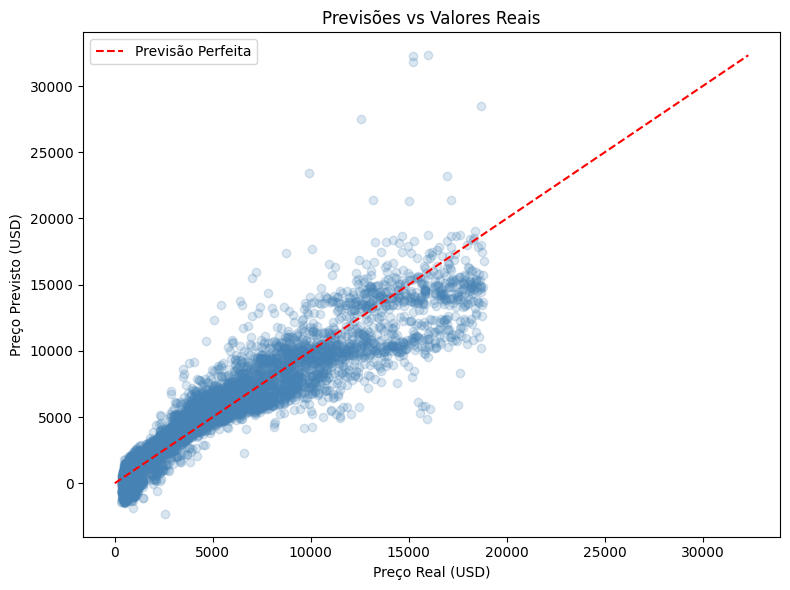

In [17]:
# Gráfico: Previsões vs Valores Reais
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.2, color='steelblue')

# Linha perfeita (onde real == previsto)
lim = max(y_test.max(), y_pred.max())
plt.plot([0, lim], [0, lim], color='red', linestyle='--', label='Previsão Perfeita')

plt.xlabel('Preço Real (USD)')
plt.ylabel('Preço Previsto (USD)')
plt.title('Previsões vs Valores Reais')
plt.legend()
plt.tight_layout()
plt.show()

> **O que esse gráfico mostra?** Se o modelo fosse perfeito, todos os pontos estariam em cima da linha vermelha. Quanto mais os pontos se dispersam, mais o modelo erra. Perceba que para diamantes mais caros (eixo X > 10.000), as previsões ficam mais espalhadas — a regressão linear tem limitações!

---

## 15. Interpretando os Coeficientes

Uma das grandes vantagens da Regressão Linear é que ela é **interpretável** — você consegue entender o que o modelo aprendeu.

Cada coeficiente representa: *"se essa variável aumentar em 1 unidade (após o scaling), o preço previsto muda em X dólares"*.

In [18]:
# Extraindo os coeficientes do modelo
coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', ascending=False)

print(coeficientes.to_string(index=False))

Feature  Coeficiente
  carat  5203.339864
clarity   493.827821
    cut    73.928465
      y    27.307125
      z     8.619903
  table  -210.442552
  depth  -222.365940
  color  -456.442345
      x -1310.868175


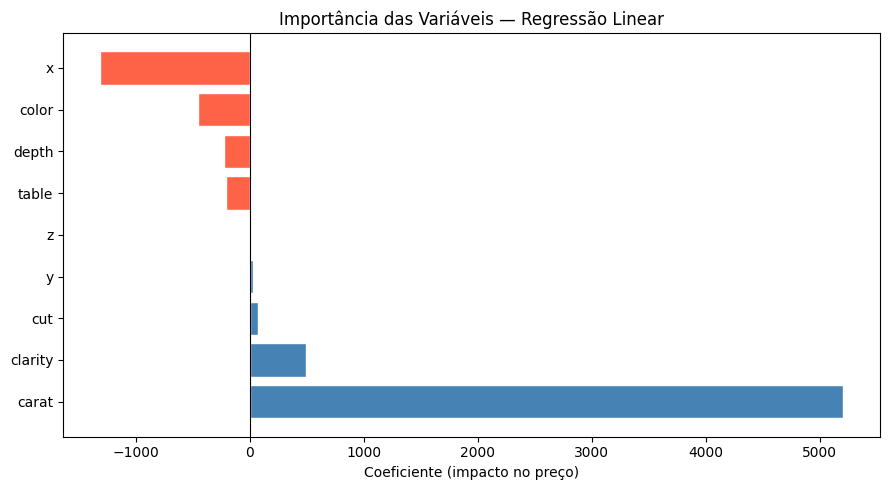

In [19]:
# Visualizando os coeficientes
cores = ['steelblue' if c > 0 else 'tomato' for c in coeficientes['Coeficiente']]

plt.figure(figsize=(9, 5))
plt.barh(coeficientes['Feature'], coeficientes['Coeficiente'], color=cores, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (impacto no preço)')
plt.title('Importância das Variáveis — Regressão Linear')
plt.tight_layout()
plt.show()

### Interpretando:

- **Azul (positivo):** quando a variável aumenta, o preço tende a **subir**
- **Vermelho (negativo):** quando a variável aumenta, o preço tende a **cair**

Vamos fazer perguntas sobre o resultado:

- **`carat` tem o maior coeficiente positivo?** Faz sentido! Diamantes maiores custam mais.
- **Alguma variável tem coeficiente negativo?** Pode parecer estranho, mas lembre-se: estamos controlando todas as outras variáveis ao mesmo tempo. Uma variável pode ter efeito negativo quando combinada com as demais.
- **`x`, `y`, `z` (dimensões físicas)?** Estão correlacionadas com o quilate — o modelo pode estar tendo dificuldade de separar o efeito de cada uma.

> **Dica:** coeficientes negativos em variáveis como `depth` e `table` podem indicar que diamantes com proporções muito extremas (muito fundos ou muito rasos) valem menos — o que faz sentido na joalheria!

---

## 16. Recapitulando o Fluxo Completo

Vamos visualizar o que fizemos hoje:

```
📊 DADOS BRUTOS
    ↓
🔍 EXPLORAÇÃO (EDA)
    ↓
🔧 PRÉ-PROCESSAMENTO
    ├── Encoding (texto → número)
    └── Scaling (equalizar escalas)
    ↓
✂️  SEPARAÇÃO (Treino / Teste)
    ↓
🧠 TREINAMENTO DO MODELO
    ↓
🔮 PREVISÕES
    ↓
📏 AVALIAÇÃO (MAE, R²)
    ↓
💡 INTERPRETAÇÃO DOS COEFICIENTES
```

Esse é o **fluxo padrão de um projeto de Machine Learning**. Você vai usar isso o resto da vida!

---

## 🏋️ Exercícios — Mão na Massa!

Agora é a sua vez. Os exercícios estão divididos em três níveis. Tente fazer todos!

---

### 🟢 Nível Fácil — Modificação simples

**Exercício 1:**
O modelo foi treinado com 80% dos dados. Tente mudar para **70% de treino e 30% de teste**.
- O MAE melhorou ou piorou?
- O que isso nos diz sobre a relação entre quantidade de dados de treino e qualidade do modelo?

In [20]:
# Exercício 1 — Seu código aqui


**Exercício 2:**
Treine o modelo **sem aplicar o scaling** (use `X_train` e `X_test` diretamente, sem passar pelo `StandardScaler`).
- Compare o MAE e R² com e sem scaling.
- O que você conclui?

In [21]:
# Exercício 2 — Seu código aqui


---

### 🟡 Nível Médio — Aplicar sozinho

**Exercício 3:**
Remova as colunas `x`, `y` e `z` do conjunto de features (argumento `drop` no pandas) e retreine o modelo.
- O desempenho mudou?
- Faz sentido remover essas colunas? Por quê?

*Dica:* `x`, `y` e `z` são as dimensões físicas do diamante. Quilate (`carat`) também mede o tamanho. Será que estamos dando informação redundante ao modelo?

In [22]:
# Exercício 3 — Seu código aqui


**Exercício 4:**
Faça um gráfico de barras mostrando os **5 maiores erros absolutos** do modelo (os 5 diamantes onde ele mais errou).
- Mostre o ID do diamante, o preço real e o preço previsto.
- Esses diamantes têm algo em comum? (olhe os dados originais usando o índice)

In [23]:
# Exercício 4 — Seu código aqui

# Dica: o erro absoluto de cada previsão é abs(y_test - y_pred)


---

### 🔴 Nível Difícil — Pensamento crítico

**Exercício 5:**
O nosso modelo tem um R² de aproximadamente 0.88. Isso parece bom!

Mas olhando o gráfico de previsões vs valores reais, percebemos que o modelo erra mais para diamantes caros (acima de $10.000).

**Hipótese:** a distribuição do preço é assimétrica (tem uma cauda longa à direita). Aplicar `log` no preço antes de treinar pode ajudar o modelo.

Tente:
1. Criar uma nova variável `y_log = np.log(y)`
2. Treinar o modelo com essa nova variável
3. Para comparar o MAE com o original, lembre de converter as previsões de volta com `np.exp(y_pred_log)`
4. O MAE melhorou?

*Dica:* para importar numpy, use `import numpy as np`

In [24]:
# Exercício 5 — Seu código aqui
import numpy as np



**Exercício 6 (Bônus):**

O dataset `diamonds` do seaborn não é o único dataset público interessante. Pesquise e carregue o dataset `tips` (gorjetas em restaurantes) com `sns.load_dataset('tips')`.

Aplique todo o pipeline que vimos hoje para prever o valor da gorjeta (`tip`) a partir das outras informações.

Perguntas para refletir:
- Quais variáveis mais influenciam a gorjeta?
- O modelo de regressão linear é adequado para esse problema?
- O R² é alto ou baixo? O que isso significa?

In [25]:
# Exercício 6 — Seu código aqui


---

## 🎯 Resumo da Aula

Hoje você aprendeu:

| Conceito | Em uma frase |
|---|---|
| **Machine Learning** | Ensinar o computador a encontrar padrões em dados |
| **Modelo** | A "função" que transforma características em previsões |
| **Treino/Teste** | Dividir dados para avaliar o modelo em exemplos que ele nunca viu |
| **Encoding** | Transformar categorias (texto) em números |
| **Scaling** | Colocar todas as variáveis na mesma escala |
| **Aprendizado Supervisionado** | Treinar com exemplos que já têm a resposta correta |
| **Regressão Linear** | Modelo que usa uma reta para prever valores numéricos |
| **MAE** | Erro médio em unidade original (ex: $800 de erro médio) |
| **R²** | % da variação explicada pelo modelo |
| **Coeficientes** | O "peso" de cada variável na previsão final |

---

*Boa sorte nos exercícios!*